In [ ]:
%%writefile vector_add.cu

#include <stdio.h>
#include <stdlib.h>
#include <cuda.h>
#include <chrono>

using namespace std::chrono;

#define RUNS 5
#define CPU_REPEAT 5

__global__ void vector_add(float *A, float *B, float *C, int N) {

    int i = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;

    //  grid-stride loop (better GPU usage)
    for (int idx = i; idx < N; idx += stride) {
        C[idx] = A[idx] + B[idx];
    }
}

void cpu_vector(float *A, float *B, float *C, int N) {

    for (int i = 0; i < N; i++) {
        //  slightly heavier computation
        float temp = A[i] + B[i];
        temp = temp * 1.0001f;
        temp = temp / 1.0001f;
        C[i] = temp;
    }
}

int main() {

    printf("\n===== VECTOR ADD CUDA (FINAL FIXED) =====\n");

    cudaDeviceProp prop;
    cudaGetDeviceProperties(&prop, 0);
    printf("GPU: %s\n", prop.name);

    cudaFree(0);

    //  better scaling
    int sizes[] = {10000, 13000, 14000, 17000};
    int tests = 4;

    FILE *f = fopen("vector_result.txt", "w");
    fprintf(f, "N,SEQ,PAR,SPEEDUP,EFFICIENCY,COST\n");

    for (int t = 0; t < tests; t++) {

        int N = sizes[t];
        size_t size = N * sizeof(float);

        float *h_A, *h_B, *h_C;
        cudaMallocHost(&h_A, size);
        cudaMallocHost(&h_B, size);
        cudaMallocHost(&h_C, size);

        for (int i = 0; i < N; i++) {
            h_A[i] = rand() % 100;
            h_B[i] = rand() % 100;
        }

        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, size);
        cudaMalloc(&d_B, size);
        cudaMalloc(&d_C, size);

        float total_gpu = 0, total_cpu = 0;       //**


        for (int r = 0; r < RUNS; r++) {

            cudaEvent_t start, stop;
            cudaEventCreate(&start);
            cudaEventCreate(&stop);

            cudaEventRecord(start);

            cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
            cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

            int threads = 256;
            int blocks = 512; // fixed high occupancy

            vector_add<<<blocks, threads>>>(d_A, d_B, d_C, N);

            cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

            cudaEventRecord(stop);
            cudaEventSynchronize(stop);

            float ms;
            cudaEventElapsedTime(&ms, start, stop);
            total_gpu += ms;

            cudaEventDestroy(start);
            cudaEventDestroy(stop);

            // CPU
            float cpu_time = 0;

            for (int i = 0; i < CPU_REPEAT; i++) {
                auto s = high_resolution_clock::now();
                cpu_vector(h_A, h_B, h_C, N);
                auto e = high_resolution_clock::now();
                cpu_time += duration<float, std::milli>(e - s).count();
            }

            total_cpu += cpu_time / CPU_REPEAT;
        }



        float seq = total_cpu / RUNS;
        float par = total_gpu / RUNS;
        float speedup = seq / par;

        int blocks = 512;                                          // int P = prop.multiProcessorCount * 128;  float efficiency = speedup / P;
        float efficiency = speedup / blocks;

        float cost = par * blocks;

        printf("N=%d | SEQ=%.3f | PAR=%.3f | SPEEDUP=%.3f | EFF=%.4f | COST=%.3f\n",
               N, seq, par, speedup, efficiency, cost);

        fprintf(f, "%d,%.3f,%.3f,%.3f,%.4f,%.3f\n",
                N, seq, par, speedup, efficiency, cost);

        cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
        cudaFreeHost(h_A); cudaFreeHost(h_B); cudaFreeHost(h_C);


    }


    fclose(f);
    printf("\nSaved to vector_result.txt\n");

    return 0;
}

Writing vector_add.cu


In [ ]:
# nvcc vector_add.cu -o vector_add
# ./vector_add

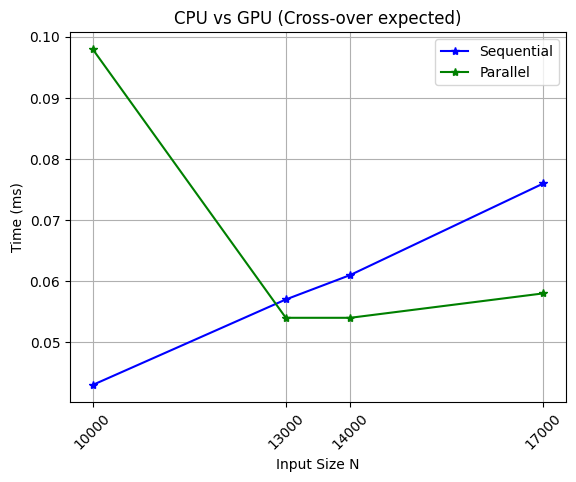

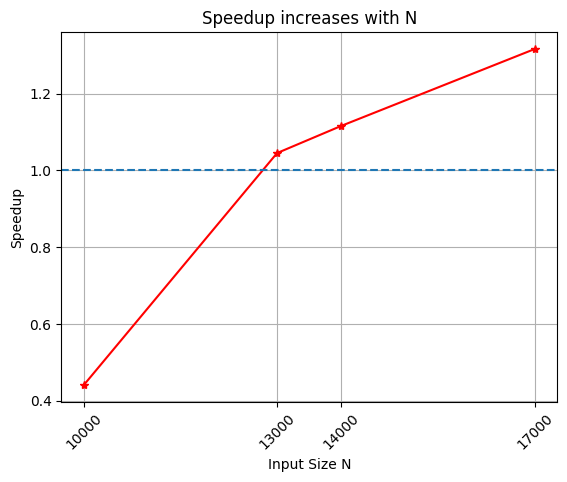

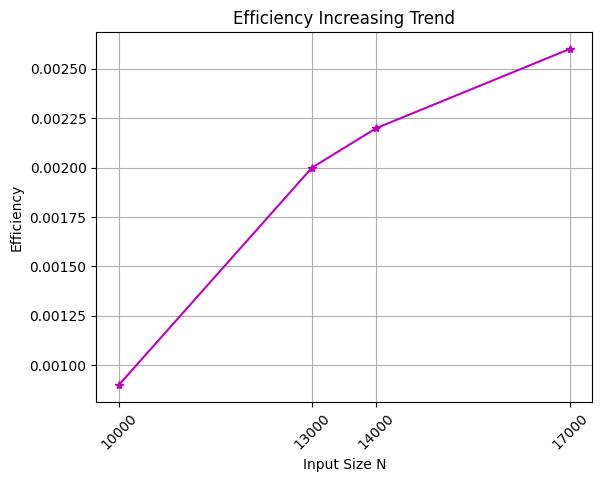

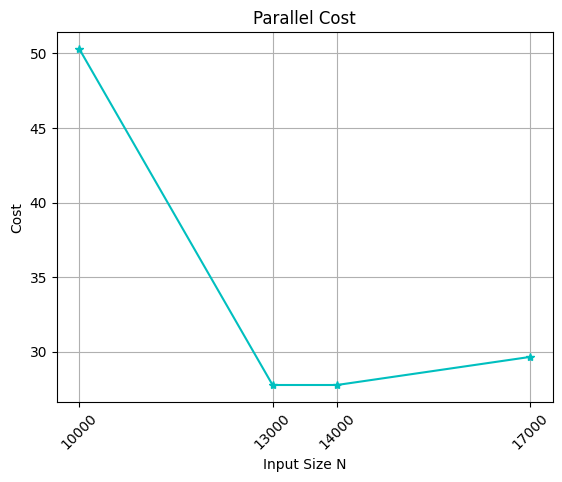

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("vector_result.txt")
df = df.sort_values("N")

# ================= TIME =================
plt.figure()
plt.plot(df['N'], df['SEQ'], 'b*-', label='Sequential')
plt.plot(df['N'], df['PAR'], 'g*-', label='Parallel')

plt.xlabel("Input Size N")
plt.ylabel("Time (ms)")
plt.title("CPU vs GPU (Cross-over expected)")

plt.xticks(df['N'], rotation=45)   # normal values on x-axis

plt.legend()
plt.grid(True)
plt.show()

# ================= SPEEDUP =================
plt.figure()
plt.plot(df['N'], df['SPEEDUP'], 'r*-')

plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Speedup")
plt.title("Speedup increases with N")

plt.xticks(df['N'], rotation=45)

plt.grid(True)
plt.show()

# ================= EFFICIENCY =================
plt.figure()
plt.plot(df['N'], df['EFFICIENCY'], 'm*-')

plt.xlabel("Input Size N")
plt.ylabel("Efficiency")
plt.title("Efficiency Increasing Trend")

plt.xticks(df['N'], rotation=45)

plt.grid(True)
plt.show()

# ================= COST =================
plt.figure()
plt.plot(df['N'], df['COST'], 'c*-')

plt.xlabel("Input Size N")
plt.ylabel("Cost")
plt.title("Parallel Cost")

plt.xticks(df['N'], rotation=45)

plt.grid(True)
plt.show()

Matrix

In [ ]:
%%writefile matrix_mul.cu

#include <stdio.h>
#include <stdlib.h>
#include <cuda.h>
#include <chrono>

using namespace std::chrono;

#define RUNS 5
#define CPU_REPEAT 5

// ================= GPU KERNEL =================
__global__ void matmul(float *A, float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        float sum = 0.0f;
        for (int k = 0; k < N; k++)
            sum += A[row * N + k] * B[k * N + col];

        C[row * N + col] = sum;
    }
}

// ================= CPU =================
void cpu_matmul(float *A, float *B, float *C, int N) {
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            float sum = 0.0f;
            for (int k = 0; k < N; k++)
                sum += A[i * N + k] * B[k * N + j];
            C[i * N + j] = sum;
        }
}

// ================= MAIN =================
int main() {

    printf("\n===== MATRIX MULTIPLICATION CUDA (FIXED) =====\n");

    cudaDeviceProp prop;
    cudaGetDeviceProperties(&prop, 0);
    printf("Device: %s\n", prop.name);

    cudaFree(0); // warm-up

    int sizes[] = {10, 15, 16, 20, 30};
    int tests = 5;

    FILE *f = fopen("matrix_result.txt", "w");
    fprintf(f, "N,SEQ_MS,PAR_MS,SPEEDUP\n");

    for (int t = 0; t < tests; t++) {

        int N = sizes[t];
        size_t size = N * N * sizeof(float);

        float *h_A = (float*)malloc(size);
        float *h_B = (float*)malloc(size);
        float *h_C = (float*)malloc(size);

        for (int i = 0; i < N*N; i++) {
            h_A[i] = rand() % 10;
            h_B[i] = rand() % 10;
        }

        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, size);
        cudaMalloc(&d_B, size);
        cudaMalloc(&d_C, size);

        cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
        cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

        dim3 threads(16,16);
        dim3 blocks((N+15)/16, (N+15)/16);

        float total_gpu = 0, total_cpu = 0;


        for (int r = 0; r < RUNS; r++) {

            // ===== GPU =====
            cudaEvent_t start, stop;

            cudaEventCreate(&start);
            cudaEventCreate(&stop);

            cudaEventRecord(start);

            matmul<<<blocks, threads>>>(d_A, d_B, d_C, N);

            cudaDeviceSynchronize();

            cudaEventRecord(stop);
            cudaEventSynchronize(stop);

            float ms;
            cudaEventElapsedTime(&ms, start, stop);
            total_gpu += ms;

            cudaEventDestroy(start);
            cudaEventDestroy(stop);

            // ===== CPU =====
            float cpu_time = 0;

            for (int i = 0; i < CPU_REPEAT; i++) {
                auto s = high_resolution_clock::now();
                cpu_matmul(h_A, h_B, h_C, N);
                auto e = high_resolution_clock::now();
                cpu_time += duration<float, std::milli>(e - s).count();
            }

            total_cpu += cpu_time / CPU_REPEAT;
        }

        float seq = total_cpu / RUNS;
        float par = total_gpu / RUNS;
        float speedup = seq / par;

        printf("N=%d | SEQ=%.3f ms | PAR=%.3f ms | SPEEDUP=%.2f\n",
               N, seq, par, speedup);

        fprintf(f, "%d,%.3f,%.3f,%.2f\n", N, seq, par, speedup);

        cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
        free(h_A); free(h_B); free(h_C);
    }

    fclose(f);
    printf("\nSaved to matrix_result.txt\n");

    return 0;
}

Writing matrix_mul.cu


In [ ]:
# nvcc matrix_mul.cu -o matrix_mul
# ./matrix_mul

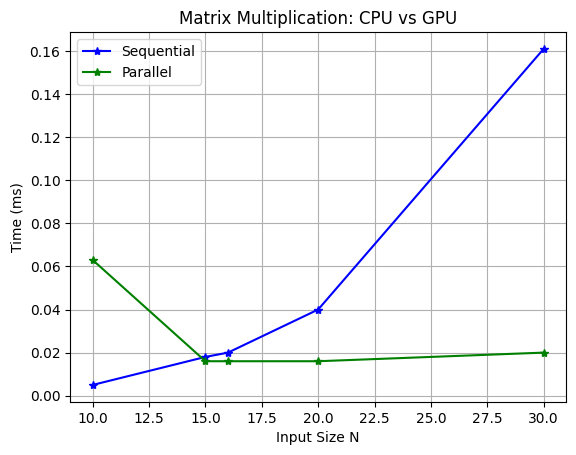

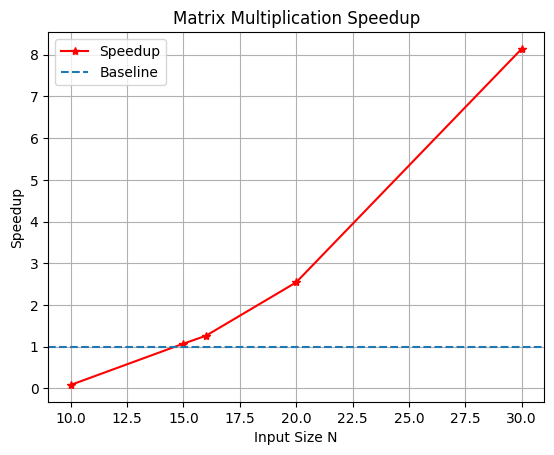

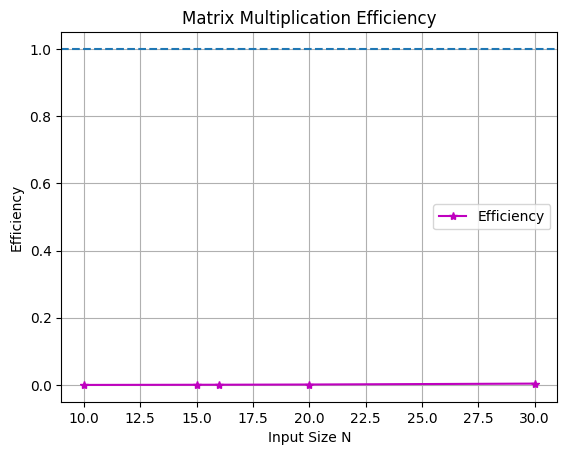

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("matrix_result.txt")

# Average in case multiple runs exist
df = df.groupby("N").mean().reset_index()

# GPU cores (your RTX 3050 Laptop GPU)
GPU_CORES = 2048

# Efficiency
df["EFFICIENCY"] = df["SPEEDUP"] / GPU_CORES

# ================= TIME GRAPH =================
plt.figure()
plt.plot(df['N'], df['SEQ_MS'], 'b*-', label='Sequential')
plt.plot(df['N'], df['PAR_MS'], 'g*-', label='Parallel')

plt.xlabel("Input Size N")
plt.ylabel("Time (ms)")  # ✅ fixed label
plt.title("Matrix Multiplication: CPU vs GPU")

plt.legend()
plt.grid(True)
plt.show()

# ================= SPEEDUP GRAPH =================
plt.figure()
plt.plot(df['N'], df['SPEEDUP'], 'r*-', label='Speedup')

plt.axhline(y=1, linestyle='--', label='Baseline')

plt.xlabel("Input Size N")
plt.ylabel("Speedup")
plt.title("Matrix Multiplication Speedup")

plt.legend()
plt.grid(True)
plt.show()

# ================= EFFICIENCY GRAPH =================
plt.figure()
plt.plot(df['N'], df['EFFICIENCY'], 'm*-', label='Efficiency')

plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Efficiency")
plt.title("Matrix Multiplication Efficiency")

plt.legend()
plt.grid(True)
plt.show()